In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube, Spectrum
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

import seaborn as sns

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join, Column, unique
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
from tqdm import tqdm
import seaborn as sns
plt.rcParams['text.usetex'] = False
pf.housestyle_rcparams()

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings('ignore', message='The following kwargs were not used by contour')

In [2]:
tab = Table(fits.open('coadd_peas_spectra.fits')[1].data)

In [3]:
rail = tab['Wavelength'][0]
grid = tab['Flux'].data

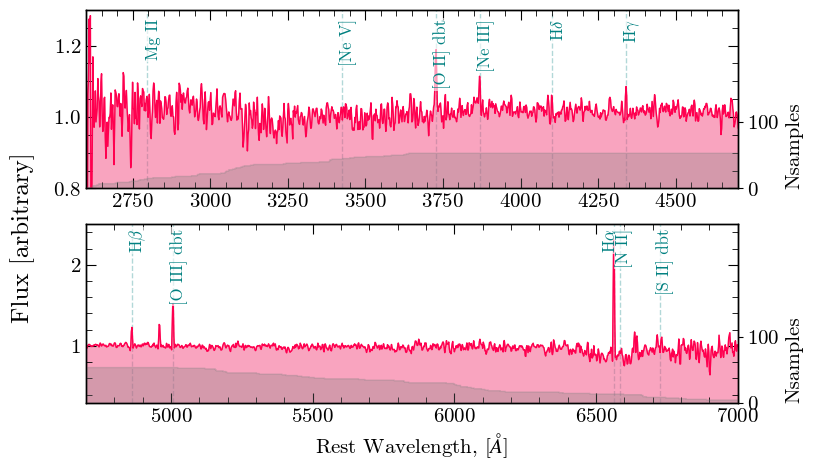

In [4]:
coadd = np.nanmean(grid, axis=0)/4e8
indicator = np.sum(~np.isnan(grid), axis=0)

# Normalize the coadded spectrum so its median is 1
median_flux = np.nanmedian(coadd)
# if median_flux > 0:
coadd += (1-median_flux)

fig, axes = plt.subplots(2, 1, figsize=(8, 5))

wave_splits = np.linspace(2400, 7000, 3)
max_indicator = np.nanmax(indicator)
twins = []

# 1. Define the lines (Wavelength: Label)
# Updated Dictionary: (Wavelength: Label)
lines = {
    1216: r"Ly$\alpha$", 1549: "C IV", 1640: "He II", 1909: "C III]",
    2798: "Mg II", 3426: "[Ne V]", 3727: "[O II] dbt", 3869: "[Ne III]", 
    4102: r"H$\delta$", 4340: r"H$\gamma$", 4861: r"H$\beta$", 
    5007: "[O III] dbt", # Representing 4959/5007
    6563: r"H$\alpha$", 6584: "[N II]", 
    6724: "[S II] dbt"  # Midpoint of 6717/6731
}



axes[0].set_ylim(0.8,1.3)
axes[1].set_ylim(0.3,2.5)
# axes[2].set_ylim(0.7,1.5)

for i, ax in enumerate(axes):
    start_wave, end_wave = wave_splits[i], wave_splits[i+1]
    
    # Filter lines for the current subplot range
    current_lines = {w: l for w, l in lines.items() if start_wave <= w <= end_wave}
    
    for line_wave, label in current_lines.items():
        # Draw the line
        ax.axvline(line_wave, color='teal', linestyle='--', alpha=0.3, lw=1, zorder=0)
        
        # Determine Y-position (using 90% of the current view)
        y_min, y_max = ax.get_ylim()
        y_pos = y_max * .98
        
        # Offset Logic for the H-alpha / [N II] cluster
        # If lines are within 40A of each other, nudge the text
        x_offset = 20
        if label == "[N II]":
            x_offset = 15 # Nudge [N II] to the right
        elif label == r"H$\alpha$":
            x_offset = -15 # Nudge H-alpha to the left
            
        ax.text(line_wave + x_offset, y_pos, label, rotation=90, 
                verticalalignment='top', horizontalalignment='center', 
                fontsize=12, color='teal', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

from scipy.signal import savgol_filter
coadd_plot = savgol_filter(coadd, window_length=5, polyorder=3)

# from spectres import spectres
# rail_coarse = np.arange(620, 9500, 10) # 10A bins instead of 2A
# coadd_plot = spectres(rail_coarse, rail, coadd)

for i, ax in enumerate(axes):
    start_wave, end_wave = wave_splits[i], wave_splits[i+1]
    
    idx = (rail >= start_wave) & (rail < end_wave)
    rail_slice = rail[idx]
    coadd_slice = coadd[idx]
    indicator_slice = indicator[idx]

    # ax.plot(rail_slice, coadd_slice, color='#ff004f', lw=1)
    # ax.fill_between(rail_slice, coadd_slice, 0, color="#f54a80", alpha=0.5)
    ax.plot(rail, coadd_plot, color='#ff004f', lw=1)
    ax.fill_between(rail, coadd_plot, 0, color="#f54a80", alpha=0.5)

    # ax.set_ylabel("Normalized Flux")
    ax.set_xlim(start_wave, end_wave)
    ax.grid(False)

    if i == len(axes) - 1:
        ax.set_xlabel(r"Rest Wavelength, [$\AA$]")

    ax2 = ax.twinx()
    
    ax2.fill_between(rail_slice, indicator_slice, color='gray', alpha=0.3, step='pre')
    
    ax2.set_ylim(0, max_indicator * 5)
    ax2.set_ylabel("Nsamples", loc='bottom')
    ax2.set_yticks([0,100])
    twins.append(ax2)

fig.tight_layout()

axes[0].set_xlim(2600)

fig.subplots_adjust(hspace=0.2)
fig.supylabel('Flux [arbitrary]', x=-0.02)


pf.fix_plot(axes)
# pf.fix_plot(twins,tickdir='out')
plt.savefig('pea_coadd.pdf', dpi=600, bbox_inches='tight')


line_center,line_type,line_center_index
Angstrom,,
float64,str10,int64
2566.0,emission,973
2576.0,emission,978
2588.0,emission,984
2600.0,emission,990
2608.0,emission,994
2612.0,emission,996
4862.0,emission,2121
4960.0,emission,2170


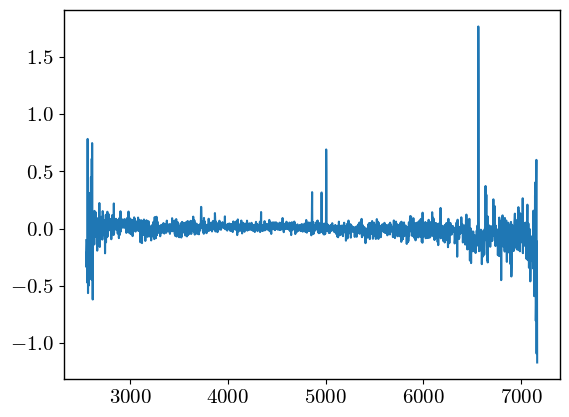

In [37]:
from specutils import Spectrum, SpectralRegion
spec_data = coadd-1
spectrum = Spectrum(flux=spec_data*u.dimensionless_unscaled, spectral_axis=rail*u.AA)
from matplotlib import pyplot as plt
plt.plot(spectrum.spectral_axis, spectrum.flux)

from specutils.manipulation import noise_region_uncertainty
noise_region = SpectralRegion(3000*u.AA, 7000*u.AA)
spectrum = noise_region_uncertainty(spectrum, noise_region)

from specutils.fitting import find_lines_threshold
lines = find_lines_threshold(spectrum, noise_factor=3)
lines[lines['line_type'] == 'emission']


        Use Spectrum instead. [warnings]
        Use Spectrum instead. [astropy.nddata.mixins.ndslicing]
        Use Spectrum instead. [specutils.spectra.spectrum]
    The maximum number of function evaluations is exceeded. [astropy.modeling.fitting]


Line Center     | Flux           
-----------------------------------
Skipping line 2566.00: Initial guess is outside of provided bounds
Skipping line 2576.00: below SNR threshold
Skipping line 2588.00: below SNR threshold
2600.00         | -1.9815e+00    
2608.00         | -5.6723e-01    
2612.00         | -6.0020e-01    
Skipping line 2636.00: below SNR threshold
2648.00         | 7.1550e-01     
2686.00         | 3.1225e-01     
2720.00         | 1.2219e+00     
2768.00         | 1.5211e+00     
2834.00         | 1.3507e+00     
Skipping line 2902.00: below SNR threshold
2984.00         | 1.3570e+00     
3728.00         | 1.6844e+00     
3868.00         | 1.6796e+00     
4340.00         | 6.5699e-01     
4862.00         | 8.8263e-01     
4960.00         | 1.1669e+00     
5006.00         | 2.6235e+00     
5992.00         | -5.8818e-01    
6090.00         | -5.1419e-02    
6176.00         | -3.9963e-01    
6562.00         | 3.3993e+00     
6636.00         | -2.2265e+00    
6644.00    

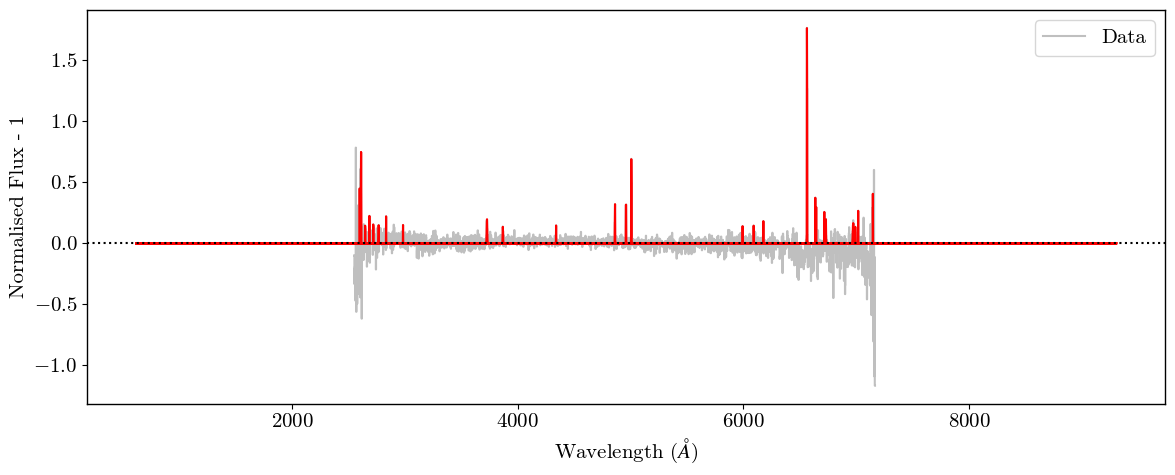

In [54]:
import numpy as np
import astropy.units as u
from matplotlib import pyplot as plt
from astropy.modeling import models
from specutils import Spectrum1D, SpectralRegion
from specutils.manipulation import noise_region_uncertainty, extract_region
from specutils.fitting import find_lines_threshold, fit_lines
from specutils.analysis import line_flux

# 1. Setup Data
rail_arr = np.array(rail)
coadd_arr = np.array(coadd)

spec_data = coadd_arr - 1
spectrum = Spectrum1D(flux=spec_data * u.dimensionless_unscaled,
                      spectral_axis=rail_arr * u.AA)

# 2. Uncertainty (using a clean region)
noise_reg = SpectralRegion(5500 * u.AA, 6000 * u.AA)
spectrum = noise_region_uncertainty(spectrum, noise_reg)

# 3. Detect Lines
lines = find_lines_threshold(spectrum, noise_factor=3)
emission_lines = lines[lines['line_type'] == 'emission']

print(f"{'Line Center':<15} | {'Flux':<15}")
print("-" * 35)

fitted_models  = []
fitted_fluxes  = [] 

wl_min = spectrum.spectral_axis.min()
wl_max = spectrum.spectral_axis.max()

for line in emission_lines:
    center_guess = line['line_center']

    # Skip lines too close to the spectral edge
    if center_guess - 20*u.AA < wl_min or center_guess + 20*u.AA > wl_max:
        print(f"Skipping line {center_guess.value:.2f}: too close to spectral edge")
        continue

    fit_window = SpectralRegion(center_guess - 20*u.AA, center_guess + 20*u.AA)

    try:
        # Extract sub-spectrum and build initial guess manually
        sub_spec = extract_region(spectrum, fit_window)

        amp_guess    = sub_spec.flux.max()
        mean_guess   = center_guess
        stddev_guess = 3 * u.AA  # adjust to your instrumental resolution

        m_init = models.Gaussian1D(
            amplitude=amp_guess,
            mean=mean_guess,
            stddev=stddev_guess
        )

        g_fit = fit_lines(spectrum, m_init, window=fit_window)

        # SNR cut: skip weak/noise detections
        if g_fit.amplitude.value / spectrum.uncertainty.array.mean() < 3:
            print(f"Skipping line {center_guess.value:.2f}: below SNR threshold")
            continue

        flux_val = line_flux(spectrum, fit_window)
        fitted_models.append(g_fit)
        fitted_fluxes.append(flux_val)
        print(f"{center_guess.value:<15.2f} | {flux_val.value:<15.4e}")

    except Exception as e:
        print(f"Skipping line {center_guess.value:.2f}: {e}")

# 4. Plot Results
plt.figure(figsize=(12, 5))
plt.step(spectrum.spectral_axis, spectrum.flux, where='mid',
         color='gray', alpha=0.5, label="Data")
for m in fitted_models:
    plt.plot(spectrum.spectral_axis, m(spectrum.spectral_axis),
             color='red', lw=1.5)
plt.axhline(0, color='black', linestyle=':')
plt.xlabel(r"Wavelength ($\AA$)")
plt.ylabel("Normalised Flux - 1")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# Known emission lines (vacuum wavelengths in Angstroms)
KNOWN_LINES = {
    "Lya":      1216.0,
    "CIV":      1549.5,
    "CIII]":    1908.7,
    "MgII":     2798.0,
    "OII":      3727.0,
    "[Ne III]": 3869.0,
    "Hd":       4102.9,
    "Hg":       4340.5,
    "OIII4363": 4363.2,
    "Hb":       4861.3,
    "OIII4959": 4958.9,
    "OIII5007": 5006.8,
    "NII6548":  6548.1,
    "Ha":       6562.8,
    "NII6583":  6583.4,
    "SII6716":  6716.4,
    "SII6731":  6730.8,
}

# Matching tolerance in Angstroms
TOLERANCE = 15.0

print(f"{'ID':<12} | {'Rest (AA)':<12} | {'Fitted (AA)':<12} | {'Flux':<15}")
print("-" * 58)

matched = []

for m, flux_val in zip(fitted_models, fitted_fluxes):  # see note below
    fitted_center = m.mean.value  # in AA

    best_name, best_rest, best_sep = None, None, np.inf
    for name, rest_wl in KNOWN_LINES.items():
        sep = abs(fitted_center - rest_wl)
        if sep < best_sep:
            best_sep = sep
            best_name = name
            best_rest = rest_wl

    if best_sep < TOLERANCE:
        matched.append({
            "id":     best_name,
            "rest":   best_rest,
            "fitted": fitted_center,
            "flux":   flux_val.value,
            "model":  m,
        })
        print(f"{best_name:<12} | {best_rest:<12.2f} | {fitted_center:<12.2f} | {flux_val.value:<15.4e}")
    else:
        print(f"{'UNKNOWN':<12} | {'---':<12} | {fitted_center:<12.2f} | {flux_val.value:<15.4e}")

ID           | Rest (AA)    | Fitted (AA)  | Flux           
----------------------------------------------------------
UNKNOWN      | ---          | 2600.05      | -1.9815e+00    
UNKNOWN      | ---          | 2612.04      | -5.6723e-01    
UNKNOWN      | ---          | 2612.02      | -6.0020e-01    
UNKNOWN      | ---          | 2648.96      | 7.1550e-01     
UNKNOWN      | ---          | 2685.99      | 3.1225e-01     
UNKNOWN      | ---          | 2720.97      | 1.2219e+00     
UNKNOWN      | ---          | 2767.11      | 1.5211e+00     
UNKNOWN      | ---          | 2833.72      | 1.3507e+00     
UNKNOWN      | ---          | 2983.33      | 1.3570e+00     
OII          | 3727.00      | 3727.32      | 1.6844e+00     
[Ne III]     | 3869.00      | 3868.34      | 1.6796e+00     
Hg           | 4340.50      | 4339.93      | 6.5699e-01     
Hb           | 4861.30      | 4861.41      | 8.8263e-01     
OIII4959     | 4958.90      | 4959.00      | 1.1669e+00     
OIII5007     | 5006.80    

In [72]:
from astropy.table import Table

matched_rows = []

for m, flux_val in zip(fitted_models, fitted_fluxes):
    fitted_center = m.mean.value

    best_name, best_rest, best_sep = None, None, np.inf
    for name, rest_wl in KNOWN_LINES.items():
        sep = abs(fitted_center - rest_wl)
        if sep < best_sep:
            best_sep = sep
            best_name = name
            best_rest = rest_wl

    if best_sep < TOLERANCE:
        matched_rows.append({
            "id":       best_name,
            "rest_wl":  best_rest,
            "fitted_wl": fitted_center,
            "dw":       fitted_center - best_rest,
            "amplitude": m.amplitude.value,
            "stddev":   m.stddev.value,
            "flux":     flux_val.value,
        })
    else:
        matched_rows.append({
            "id":       "UNKNOWN",
            "rest_wl":  np.nan,
            "fitted_wl": fitted_center,
            "dw":       np.nan,
            "amplitude": m.amplitude.value,
            "stddev":   m.stddev.value,
            "flux":     flux_val.value,
        })

results = Table(rows=matched_rows)

# Add units as column metadata
results["rest_wl"].unit  = u.AA
results["fitted_wl"].unit = u.AA
results["dw"].unit       = u.AA
results["stddev"].unit   = u.AA
results["flux"].unit     = u.dimensionless_unscaled

In [73]:
useful_results = results[results['id']!='UNKNOWN']
useful_results

id,rest_wl,fitted_wl,dw,amplitude,stddev,flux
,Angstrom,Angstrom,Angstrom,,Angstrom,
str8,float64,float64,float64,float64,float64,float64
OII,3727.0,3727.317973973146,0.31797397314585396,0.20401190301815397,2.4647188705278107,1.6844187730866258
[Ne III],3869.0,3868.336723481965,-0.663276518035218,0.13579549473091962,1.9488684562246823,1.6795807779468943
Hg,4340.5,4339.929016925568,-0.5709830744317514,0.14538092440960076,1.0217857888798558,0.656987858803548
Hb,4861.3,4861.40816777748,0.10816777748004824,0.36855028626116654,1.1125075793551584,0.882632184281662
OIII4959,4958.9,4959.000959048339,0.10095904833906388,1.8112806004901938,0.5345696486518513,1.166945135254805
OIII5007,5006.8,5006.75784415108,-0.04215584892062907,0.8401571390363562,1.2038949899824192,2.62354110582534
Ha,6562.8,6562.812104656748,0.012104656747396803,2.355980582388043,1.0676691072904045,3.3992629055382695
SII6716,6716.4,6715.791763071427,-0.6082369285722962,0.26532071613184743,0.7782031171410668,-0.2210537764483127


In [83]:
print('OIII/hbeta',f'{(2.62354110582534)/0.882632184281662}')
print('OIII/OII',f'{(2.62354110582534)/1.6844187730866258}')
3.3992629055382695/0.882632184281662

0.26/3.3992629055382695

OIII/hbeta 2.9724058929037716
OIII/OII 1.557534947807434


0.07648717007925261

In [69]:
useful_results

id,rest_wl,fitted_wl,dw,amplitude,stddev,flux
,Angstrom,Angstrom,Angstrom,,Angstrom,
str8,float64,float64,float64,float64,float64,float64
OII,3727.0,3727.317973973146,0.31797397314585396,0.20401190301815397,2.4647188705278107,1.6844187730866258
[Ne III],3869.0,3868.336723481965,-0.663276518035218,0.13579549473091962,1.9488684562246823,1.6795807779468943
Hg,4340.5,4339.929016925568,-0.5709830744317514,0.14538092440960076,1.0217857888798558,0.656987858803548
Hb,4861.3,4861.40816777748,0.10816777748004824,0.36855028626116654,1.1125075793551584,0.882632184281662
OIII4959,4958.9,4959.000959048339,0.10095904833906388,1.8112806004901938,0.5345696486518513,1.166945135254805
OIII5007,5006.8,5006.75784415108,-0.04215584892062907,0.8401571390363562,1.2038949899824192,2.62354110582534
Ha,6562.8,6562.812104656748,0.012104656747396803,2.355980582388043,1.0676691072904045,3.3992629055382695
SII6716,6716.4,6715.791763071427,-0.6082369285722962,0.26532071613184743,0.7782031171410668,-0.2210537764483127
